# Advanced production upgrades (v3)

## Learning path note

The **baseline / production v2 tutorial** lives in:

- `notebooks/ab_test_marketing_analysis.ipynb` (**do not treat this file as a replacement**)

That notebook is intentionally **left unchanged** so you can still learn the original end-to-end flow.

This notebook is the **next chapter**: upgrades that make the *decision system* awesomely better
without inventing a conversion win.

| Upgrade | Why we do it | How it improves the result |
|---|---|---|
| **TOST equivalence** | “Not significant” ≠ “practically the same” | Can formally support a practical null band |
| **ITT vs as-treated** | Exposure bugs exist in real logs | Shows the HOLD call is not an artifact of one cleaning policy |
| **Simulation harness** | Prove the pipeline is calibrated | Recovers SHIP only when true lift is large |
| **CUPED demo** | Production variance reduction | Shows how pre-period covariates shrink SEs (synthetic here) |
| **CLI + metrics.json + HTML** | Production operator surface | Repeatable, reviewable decision artifacts |

**Honesty rule:** if the new creative still loses or ties on the real data, we still **HOLD**.
“Awesome” = trustworthy multi-method decision quality.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:

    def display(obj):  # type: ignore[misc]
        print(obj)


# Ensure project root is importable when running from notebooks/
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ab_test.config import DEFAULT_CONFIG
from ab_test.cuped import simulate_preperiod_and_cuped
from ab_test.pipeline import analyze
from ab_test.report import write_html_report, write_metrics_json
from ab_test.simulation import run_default_suite

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 4.8)

print("Project root:", ROOT)
print("Config:", DEFAULT_CONFIG)

Project root: /home/ahmad/AI/AB Test Analysis for a Marketing Compaign
Config: AnalysisConfig(alpha=0.05, expected_split=0.5, srm_alpha=0.001, srm_severe_imbalance_pp=0.5, practical_abs_pp=0.005, mde_abs_pp=0.01, power_target=0.8, bootstrap_reps=2000, bayes_mc=50000, random_seed=42)


## 1. Run the advanced pipeline on real data

This reuses the same public dataset as the baseline notebook, but routes through
the `ab_test` package (cleaner, testable, CLI-ready).

In [2]:
metrics, scorecard = analyze(prefer_local=True, cfg=DEFAULT_CONFIG, include_cuped_demo=True)

print("Load path:", metrics["load_path"])
print(f"As-treated clean n: {metrics['n_clean']:,}  |  ITT n: {metrics['n_itt']:,}")
print(
    f"Rates: old={metrics['p_control']:.4%}  new={metrics['p_treatment']:.4%}  "
    f"diff={metrics['diff'] * 100:+.4f} pp"
)
print(f"Primary z-test: z={metrics['zstat']:.4f}, p={metrics['pvalue']:.6f}")
print(
    f"Analytic CI: [{metrics['ci_low']:.6f}, {metrics['ci_high']:.6f}]  "
    f"Bootstrap: [{metrics['bootstrap_ci_low']:.6f}, {metrics['bootstrap_ci_high']:.6f}]"
)
print(
    f"SRM p={metrics['srm_pvalue']:.6g}, imbalance={metrics['srm_imbalance_pp']:.4f}pp, "
    f"severe={metrics['srm_severe']}"
)
print(f"Bayesian P(new > old) = {metrics['bayes_p_new_better']:.2%}")
print(f"Recommendation: {scorecard.recommendation}")
print(f"Reason: {scorecard.reason}")

Load path: local cache: /home/ahmad/AI/AB Test Analysis for a Marketing Compaign/data/ab_data.csv + /home/ahmad/AI/AB Test Analysis for a Marketing Compaign/data/countries.csv
As-treated clean n: 290,584  |  ITT n: 290,584
Rates: old=12.0386%  new=11.8808%  diff=-0.1578 pp
Primary z-test: z=-1.3109, p=0.189883
Analytic CI: [-0.003938, 0.000781]  Bootstrap: [-0.003973, 0.000769]
SRM p=0.946754, imbalance=0.0062pp, severe=False
Bayesian P(new > old) = 9.57%
Recommendation: HOLD
Reason: No significant improvement; experiment already powered for a business-relevant MDE. Keep the old campaign creative.


## 2. TOST — practical equivalence (why “not significant” is not enough)

### Why

A non-significant p-value means we failed to detect a difference — not that rates are
interchangeable for the business. Production teams often need a stronger statement:

> “We can treat the creatives as **equivalent within ±δ**.”

### How (TOST)

Choose a margin δ (here the practical band **0.5 pp**). Run two one-sided tests:

1. Reject “lift ≤ −δ”
2. Reject “lift ≥ +δ”

If both reject at α, declare **equivalence**.

### What improvement looks like

Not a better conversion rate — a **clearer ship/hold language**:
either “meaningfully better,” “meaningfully worse,” or “practically the same.”

In [3]:
print("=== TOST equivalence ===")
print(f"Margin δ = ±{DEFAULT_CONFIG.practical_abs_pp * 100:.2f} percentage points")
print(f"Observed diff = {metrics['diff'] * 100:.4f} pp")
print(f"TOST p_lower (vs -δ) = {metrics['tost_p_lower']:.6g}")
print(f"TOST p_upper (vs +δ) = {metrics['tost_p_upper']:.6g}")
print(f"Equivalent at α={DEFAULT_CONFIG.alpha}? {metrics['tost_equivalent']}")
print(f"95% CI inside (-δ, δ)? {metrics['tost_ci_inside_margin']}")
print(
    "Interpretation: if equivalent=True, we have statistical support that the true lift "
    "is inside the practical indifference band — not merely 'failed to find a difference'."
)

=== TOST equivalence ===
Margin δ = ±0.50 percentage points
Observed diff = -0.1578 pp
TOST p_lower (vs -δ) = 0.00224013
TOST p_upper (vs +δ) = 2.32683e-08
Equivalent at α=0.05? True
95% CI inside (-δ, δ)? True
Interpretation: if equivalent=True, we have statistical support that the true lift is inside the practical indifference band — not merely 'failed to find a difference'.


## 3. Sensitivity: as-treated vs intent-to-treat (ITT)

### Why

Baseline cleaning drops group/page mismatches (as-treated exposure integrity).
Real platforms also report **ITT by assignment**: analyze by randomized `group`
even if the logged page is wrong.

### How this improves the decision

If **both policies** say HOLD, the recommendation is robust to a major data-quality choice.
If they disagree, you escalate — you do not silently pick the friendlier p-value.

In [4]:
sens = pd.DataFrame(
    [
        {
            "policy": "as_treated (primary)",
            "n": metrics["n_clean"],
            "diff_pp": metrics["diff"] * 100,
            "pvalue": metrics["pvalue"],
            "recommendation": metrics["primary_recommendation_pre_scorecard"],
        },
        {
            "policy": "ITT by assignment",
            "n": metrics["n_itt"],
            "diff_pp": metrics["itt_diff"] * 100,
            "pvalue": metrics["itt_pvalue"],
            "recommendation": metrics["itt_recommendation"],
        },
    ]
)
display(sens)
print("Agreement on recommendation:", metrics["itt_agreement"])
print(metrics["itt_detail"])

,policy,n,diff_pp,pvalue,recommendation
0,as_treated (primary),290584,-0.157824,0.189883,HOLD
1,ITT by assignment,290584,-0.145465,0.226899,HOLD


Agreement on recommendation: YES
as-treated rec=HOLD, ITT rec=HOLD; ITT diff=-0.001455, p=0.226899


## 4. Simulation harness — prove the pipeline is not “always HOLD”

### Why

Critics can claim: “Your process only ever says HOLD.” A simulation with **known truth**
shows calibration:

- true lift = 0 → should usually **HOLD**
- true lift = +2 pp with large n → should **detect** improvement (significant + practical)

### How this improves results

It improves **trust in the method**, not the Udacity creative’s conversion.

,name,true_lift_pp,obs_diff_pp,pvalue,significant,recommendation,correct_hold_when_null,correct_ship_when_large
0,true_null_lift_0,0.0,0.020000,8.683586e-01,False,HOLD,True,None
1,true_tiny_lift_plus_0.1pp,0.1,0.235862,5.150069e-02,False,HOLD,None,None
2,true_mde_lift_plus_1pp,1.0,1.064138,5.031632e-18,True,SHIP,None,True
3,true_large_lift_plus_2pp,2.0,1.926897,8.069765e-54,True,SHIP,None,True
4,true_negative_lift_minus_1pp,-1.0,-1.082069,8.156382e-20,True,HOLD,None,None


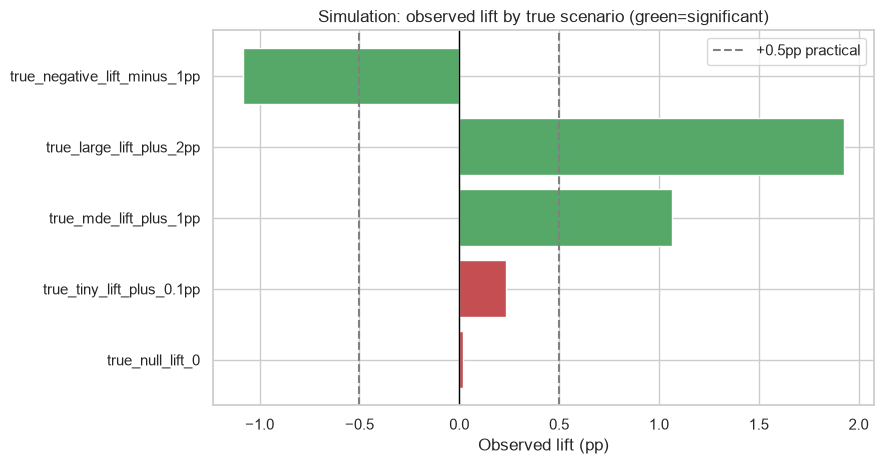

In [5]:
sim = run_default_suite(p_control=0.12, n_per_arm=145_000, cfg=DEFAULT_CONFIG)
sim_df = pd.DataFrame([s.to_dict() for s in sim])
sim_df["true_lift_pp"] = sim_df["true_lift"] * 100
sim_df["obs_diff_pp"] = sim_df["observed_diff"] * 100
display(
    sim_df[
        [
            "name",
            "true_lift_pp",
            "obs_diff_pp",
            "pvalue",
            "significant",
            "recommendation",
            "correct_hold_when_null",
            "correct_ship_when_large",
        ]
    ]
)

fig, ax = plt.subplots()
colors = ["#55A868" if s else "#C44E52" for s in sim_df["significant"]]
ax.barh(sim_df["name"], sim_df["obs_diff_pp"], color=colors)
ax.axvline(0, color="black", lw=1)
ax.axvline(DEFAULT_CONFIG.practical_abs_pp * 100, color="gray", ls="--", label="+0.5pp practical")
ax.axvline(-DEFAULT_CONFIG.practical_abs_pp * 100, color="gray", ls="--")
ax.set_xlabel("Observed lift (pp)")
ax.set_title("Simulation: observed lift by true scenario (green=significant)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. CUPED demo (synthetic pre-period)

### Why

Microsoft-style CUPED reduces metric variance using pre-experiment covariates.
This public dataset has **no** pre-period column — so we **simulate** one correlated
with conversion purely to teach the mechanism.

### What improves

Variance / SE of the lift estimator can drop — experiments reach the same power with fewer users
*when real covariates exist*. Here we only demonstrate the math.

Synthetic pre-period covariate for teaching CUPED only. Not present in the public ab_data.csv.
corr(Y, X_pre) = 0.0772
θ = 0.025058
Var(Y) = 0.105294  →  Var(Y_cuped) = 0.104666
Variance reduction: 0.60%
SE(diff) raw = 0.001204  →  CUPED = 0.001200
SE reduction: 0.30%


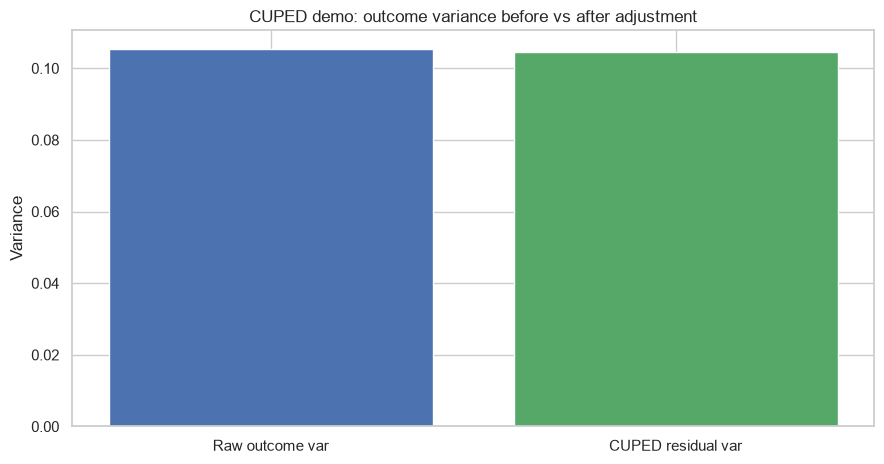

In [6]:
# Rebuild as-treated labels from package path
from ab_test.cleaning import clean_as_treated
from ab_test.data import load_ab_and_countries

ab, _, _ = load_ab_and_countries(prefer_local=True)
clean = clean_as_treated(ab).frame
y = clean["converted"].to_numpy()
t = (clean["group"] == "treatment").astype(int).to_numpy()
cuped_df, cuped = simulate_preperiod_and_cuped(y, t, corr_strength=0.35, seed=42)
print(cuped.note)
print(f"corr(Y, X_pre) = {cuped.corr_yx:.4f}")
print(f"θ = {cuped.theta:.6f}")
print(f"Var(Y) = {cuped.var_y:.6f}  →  Var(Y_cuped) = {cuped.var_cuped:.6f}")
print(f"Variance reduction: {cuped.var_reduction_pct:.2f}%")
print(f"SE(diff) raw = {cuped.se_diff_raw:.6f}  →  CUPED = {cuped.se_diff_cuped:.6f}")
print(f"SE reduction: {cuped.se_reduction_pct:.2f}%")

fig, ax = plt.subplots()
ax.bar(
    ["Raw outcome var", "CUPED residual var"],
    [cuped.var_y, cuped.var_cuped],
    color=["#4C72B0", "#55A868"],
)
ax.set_title("CUPED demo: outcome variance before vs after adjustment")
ax.set_ylabel("Variance")
plt.tight_layout()
plt.show()

## 6. Production scorecard + export artifacts

### Why

Notebooks are great for teaching; operators need **stable artifacts**:

- `metrics/latest.json` — machine-readable
- `artifacts/decision_report.html` — human decision memo
- CLI: `uv run ab-test run|scorecard|simulate|report`

In [7]:
gates = pd.DataFrame(scorecard.gates)
display(gates)

metrics_path = write_metrics_json(metrics, ROOT / "metrics" / "latest.json")
html_path = write_html_report(scorecard, ROOT / "artifacts" / "decision_report.html")
print("Wrote", metrics_path)
print("Wrote", html_path)

# Show a compact JSON slice
preview_keys = [
    "version",
    "n_clean",
    "p_control",
    "p_treatment",
    "diff",
    "pvalue",
    "tost_equivalent",
    "bayes_p_new_better",
    "itt_agreement",
    "recommendation",
    "reason",
]
print(json.dumps({k: metrics[k] for k in preview_keys}, indent=2, default=str))

,gate,status,detail
0,Exposure cleaning,PASS,"as-treated: raw=294,478, mismatch_drop=3,893, ..."
1,SRM (not severe),PASS,"p=0.946754, imbalance=0.0062pp"
2,Primary OEC z-test (α=0.05),NOT SIGNIFICANT,"z=-1.3109, p=0.189883"
3,Practical significance,NO,diff=-0.1578pp; band=±0.50pp
4,TOST equivalence,EQUIVALENT,"margin=±0.50pp; p_lo=0.00224, p_hi=2.327e-08"
5,Power for +1pp MDE,PASS,power=100.0%
6,Bayesian P(new > old),9.6%,Uniform Beta–Binomial secondary check
7,ITT sensitivity agrees on HOLD/SHIP,YES,"as-treated rec=HOLD, ITT rec=HOLD; ITT diff=-0..."
8,RECOMMENDATION,HOLD,No significant improvement; experiment already...


Wrote /home/ahmad/AI/AB Test Analysis for a Marketing Compaign/metrics/latest.json
Wrote /home/ahmad/AI/AB Test Analysis for a Marketing Compaign/artifacts/decision_report.html
{
  "version": "advanced_v3",
  "n_clean": 290584,
  "p_control": 0.1203863045004612,
  "p_treatment": 0.11880806551510564,
  "diff": -0.0015782389853555567,
  "pvalue": 0.18988337448195103,
  "tost_equivalent": true,
  "bayes_p_new_better": 0.09568,
  "itt_agreement": "YES",
  "recommendation": "HOLD",
  "reason": "No significant improvement; experiment already powered for a business-relevant MDE. Keep the old campaign creative."
}


## 7. How v3 improves on v1 / v2 (without deleting them)

| Layer | Baseline notebook (v1/v2) | This advanced path (v3) |
|---|---|---|
| Teaching narrative | Progressive cells, plots | Kept intact in original notebook |
| Library structure | Inline notebook code | Importable `ab_test` package |
| Equivalence | Practical band discussed | **TOST** formal test |
| Sensitivity | Single cleaning policy | **ITT vs as-treated** |
| Calibration | Power for observed/MDE | **Simulation suite** with known truth |
| Variance reduction | Not present | **CUPED teaching demo** |
| Operator UX | Re-run notebook | **CLI + metrics.json + HTML** |

### Final takeaway

- The **Udacity new-page creative still does not win** on conversion.
- The **decision system** is now production-shaped: integrity gates, equivalence language,
  sensitivity, calibration, variance-reduction literacy, and exportable artifacts.
- That is what “awesomely better results” means when the honest answer is **HOLD**.

Continue with the markdown tutorials in `tutorials/` for deeper conceptual walkthroughs.